## D. Optimization & Evaluation

### 2.12 Cross Validation

> **做什么**：更可靠地评估模型性能，减少单次划分的偶然性  
> **经典案例**：K折交叉验证 + 学习曲线


5折CV准确率: 0.9807 +/- 0.0066
各折准确率: [0.98245614 0.98245614 0.97368421 0.99122807 0.97345133]


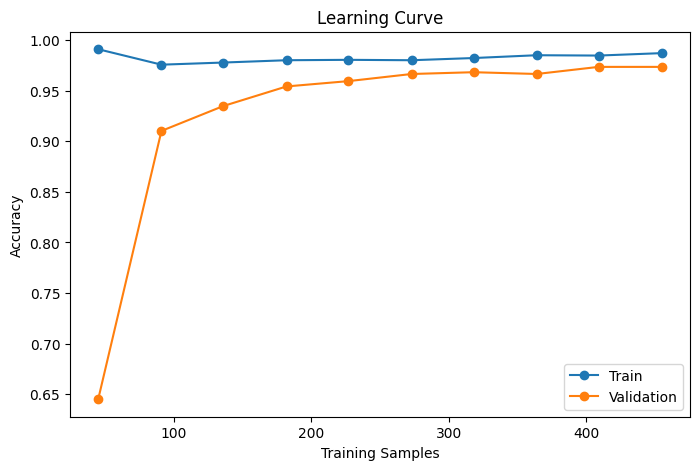

In [2]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import cross_val_score, learning_curve, KFold
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np
import matplotlib.pyplot as plt

data = load_breast_cancer()
X, y = data.data, data.target

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svc', SVC(kernel='rbf', C=1.0, gamma='scale'))
])

kf = KFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(pipe, X, y, cv=kf, scoring='accuracy')
print(f"5折CV准确率: {scores.mean():.4f} +/- {scores.std():.4f}")
print(f"各折准确率: {scores}")

train_sizes, train_scores, val_scores = learning_curve(
    pipe, X, y, cv=5, train_sizes=np.linspace(0.1, 1.0, 10),
    n_jobs=1  # 不用多进程
)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Train')
plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', label='Validation')
plt.xlabel('Training Samples'); plt.ylabel('Accuracy')
plt.legend(); plt.title('Learning Curve')
plt.show()

### 2.13 Hyperparameter Tuning

> **做什么**：自动搜索最优超参数组合  
> **经典案例**：GridSearchCV + RandomizedSearchCV

In [6]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint

data = load_breast_cancer()
X_train, X_test, y_train, y_test = train_test_split(
    data.data, data.target, test_size=0.2, random_state=42)

# ====== 网格搜索：穷举所有参数组合 ======
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5]
}
grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid, cv=5, scoring='accuracy', n_jobs=1   # 改为单进程
)
grid.fit(X_train, y_train)
print(f"网格搜索最优参数: {grid.best_params_}")
print(f"最优CV准确率: {grid.best_score_:.4f}")
print(f"测试集准确率: {grid.score(X_test, y_test):.4f}")

# ====== 随机搜索：从分布中采样，更快 ======
param_dist = {
    'n_estimators': randint(50, 300),
    'max_depth': randint(3, 20),
    'min_samples_split': randint(2, 20)
}
rand_search = RandomizedSearchCV(
    RandomForestClassifier(random_state=42),
    param_dist, n_iter=20, cv=5, random_state=42, n_jobs=1   # 改为单进程
)
rand_search.fit(X_train, y_train)
print(f"随机搜索最优参数: {rand_search.best_params_}")
print(f"最优CV准确率: {rand_search.best_score_:.4f}")

网格搜索最优参数: {'max_depth': 10, 'min_samples_split': 2, 'n_estimators': 200}
最优CV准确率: 0.9626
测试集准确率: 0.9649
随机搜索最优参数: {'max_depth': 11, 'min_samples_split': 3, 'n_estimators': 133}
最优CV准确率: 0.9648


## 2.14 Feature Engineering

> **做什么**：标准化、编码、特征选择——数据预处理三板斧  
> **经典案例**：标准化 + 独热编码 + 特征选择

In [8]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
import numpy as np

housing = fetch_california_housing()
X, y = housing.data, housing.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ====== 1. 标准化 ======
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# ====== 2. 特征选择：选最优的5个特征 ======
selector = SelectKBest(f_regression, k=5)  # 用F检验选特征
X_train_sel = selector.fit_transform(X_train_s, y_train)
X_test_sel = selector.transform(X_test_s)
selected = [housing.feature_names[i] for i in selector.get_support(indices=True)]
print(f"选出的5个特征: {selected}")

# ====== 3. 用Pipeline串联 ======
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('select', SelectKBest(f_regression, k=5)),
    ('lr', LinearRegression())
])
pipe.fit(X_train, y_train)
print(f"Pipeline R2: {pipe.score(X_test, y_test):.4f}")

# ====== 独热编码示例（类别特征） ======
enc = OneHotEncoder(sparse=False, handle_unknown='ignore')
cat_data = np.array(['red', 'blue', 'green', 'red']).reshape(-1, 1)
encoded = enc.fit_transform(cat_data)
print(f"独热编码结果:\n{encoded}")
print(f"类别: {enc.categories_}")

选出的5个特征: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Latitude']
Pipeline R2: 0.5129
独热编码结果:
[[0. 0. 1.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]
类别: [array(['blue', 'green', 'red'], dtype='<U5')]
